# RAG Ablation — Single Composite Figure
**MSc Project: Trustworthy SLMs for Ambient Clinical Scribing**

Produces one publication-quality composite figure with three rows:
- **Row 1 (a–c)**: Overall metrics grouped bar chart
- **Row 2 (d–f)**: Per-section ROUGE-L heatmap
- **Row 3 (g–i)**: Delta gains over Dense Only baseline

Counts as a single figure in your dissertation (one caption, one figure number).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         9,
    'axes.titlesize':    10,
    'axes.labelsize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})
print('Libraries loaded.')

Libraries loaded.


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# DATA — transcribed exactly from table_c_rag_ablation.md
# ══════════════════════════════════════════════════════════════════════════════

MODELS   = ['Phi-3.5\n(3.8B)', 'Llama-3.2\n(3B)', 'Llama-3.2\n(1B)']
MODELS_FULL = ['Phi-3.5 (3.8B)', 'Llama-3.2 (3B)', 'Llama-3.2 (1B)']
CONFIGS  = ['Dense Only', 'Dense+Rerank', 'Dense+Rerank+QE', 'Full Medical']
SECTIONS = ['Chief\nComplaint', 'HPI', 'Past\nMedical Hx',
            'Medications', 'Allergies', 'Examination',
            'Assessment', 'Plan', 'Safety\nNetting']

# Overall metrics [model_idx][config_idx]
overall = {
    'ROUGE-L': [
        [0.536, 0.627, 0.632, 0.632],
        [0.626, 0.632, 0.636, 0.632],
        [0.599, 0.596, 0.600, 0.595],
    ],
    'MEDCON-F1': [
        [0.743, 0.765, 0.778, 0.767],
        [0.788, 0.791, 0.800, 0.794],
        [0.772, 0.774, 0.773, 0.766],
    ],
    'Judge Avg': [
        [4.33, 4.36, 4.43, 4.33],
        [4.35, 4.33, 4.35, 4.31],
        [4.15, 4.11, 4.09, 4.18],
    ],
}

# Teacher mean ± SD
teacher = {
    'ROUGE-L':   (0.428, 0.004),
    'MEDCON-F1': (0.660, 0.003),
    'Judge Avg': (4.757, 0.006),
}

# Per-section ROUGE-L [model_idx][config_idx][section_idx]
section_rouge = [
    [  # Phi-3.5
        [0.863, 0.456, 0.857, 0.884, 0.809, 0.620, 0.420, 0.411, 0.213],
        [0.850, 0.507, 0.844, 0.882, 0.764, 0.661, 0.495, 0.489, 0.585],
        [0.849, 0.484, 0.877, 0.901, 0.784, 0.692, 0.524, 0.501, 0.589],
        [0.859, 0.513, 0.842, 0.902, 0.772, 0.685, 0.509, 0.509, 0.595],
    ],
    [  # Llama-3B
        [0.837, 0.501, 0.793, 0.821, 0.845, 0.676, 0.467, 0.481, 0.598],
        [0.836, 0.487, 0.849, 0.860, 0.856, 0.697, 0.489, 0.485, 0.606],
        [0.840, 0.503, 0.831, 0.858, 0.837, 0.697, 0.490, 0.497, 0.614],
        [0.841, 0.487, 0.853, 0.864, 0.846, 0.704, 0.492, 0.485, 0.605],
    ],
    [  # Llama-1B
        [0.812, 0.441, 0.774, 0.833, 0.827, 0.671, 0.455, 0.463, 0.577],
        [0.819, 0.443, 0.754, 0.840, 0.798, 0.675, 0.462, 0.476, 0.571],
        [0.814, 0.436, 0.773, 0.869, 0.817, 0.679, 0.508, 0.463, 0.575],
        [0.813, 0.432, 0.753, 0.825, 0.822, 0.668, 0.475, 0.460, 0.570],
    ],
]

# Colour scheme
MODEL_COLS = [
    ['#1A6BAF','#3A8FD4','#6BAFD4','#A8D4EF'],  # blues  — Phi-3.5
    ['#1A7A4A','#3A9D6A','#6ABD8A','#A8DDB8'],  # greens — Llama-3B
    ['#B85C00','#E07820','#F0A060','#F8CFA0'],  # oranges— Llama-1B
]
MODEL_BASE  = ['#1A6BAF', '#1A7A4A', '#B85C00']
MODEL_MARK  = ['o', 's', '^']

print('Data loaded.')

Data loaded.


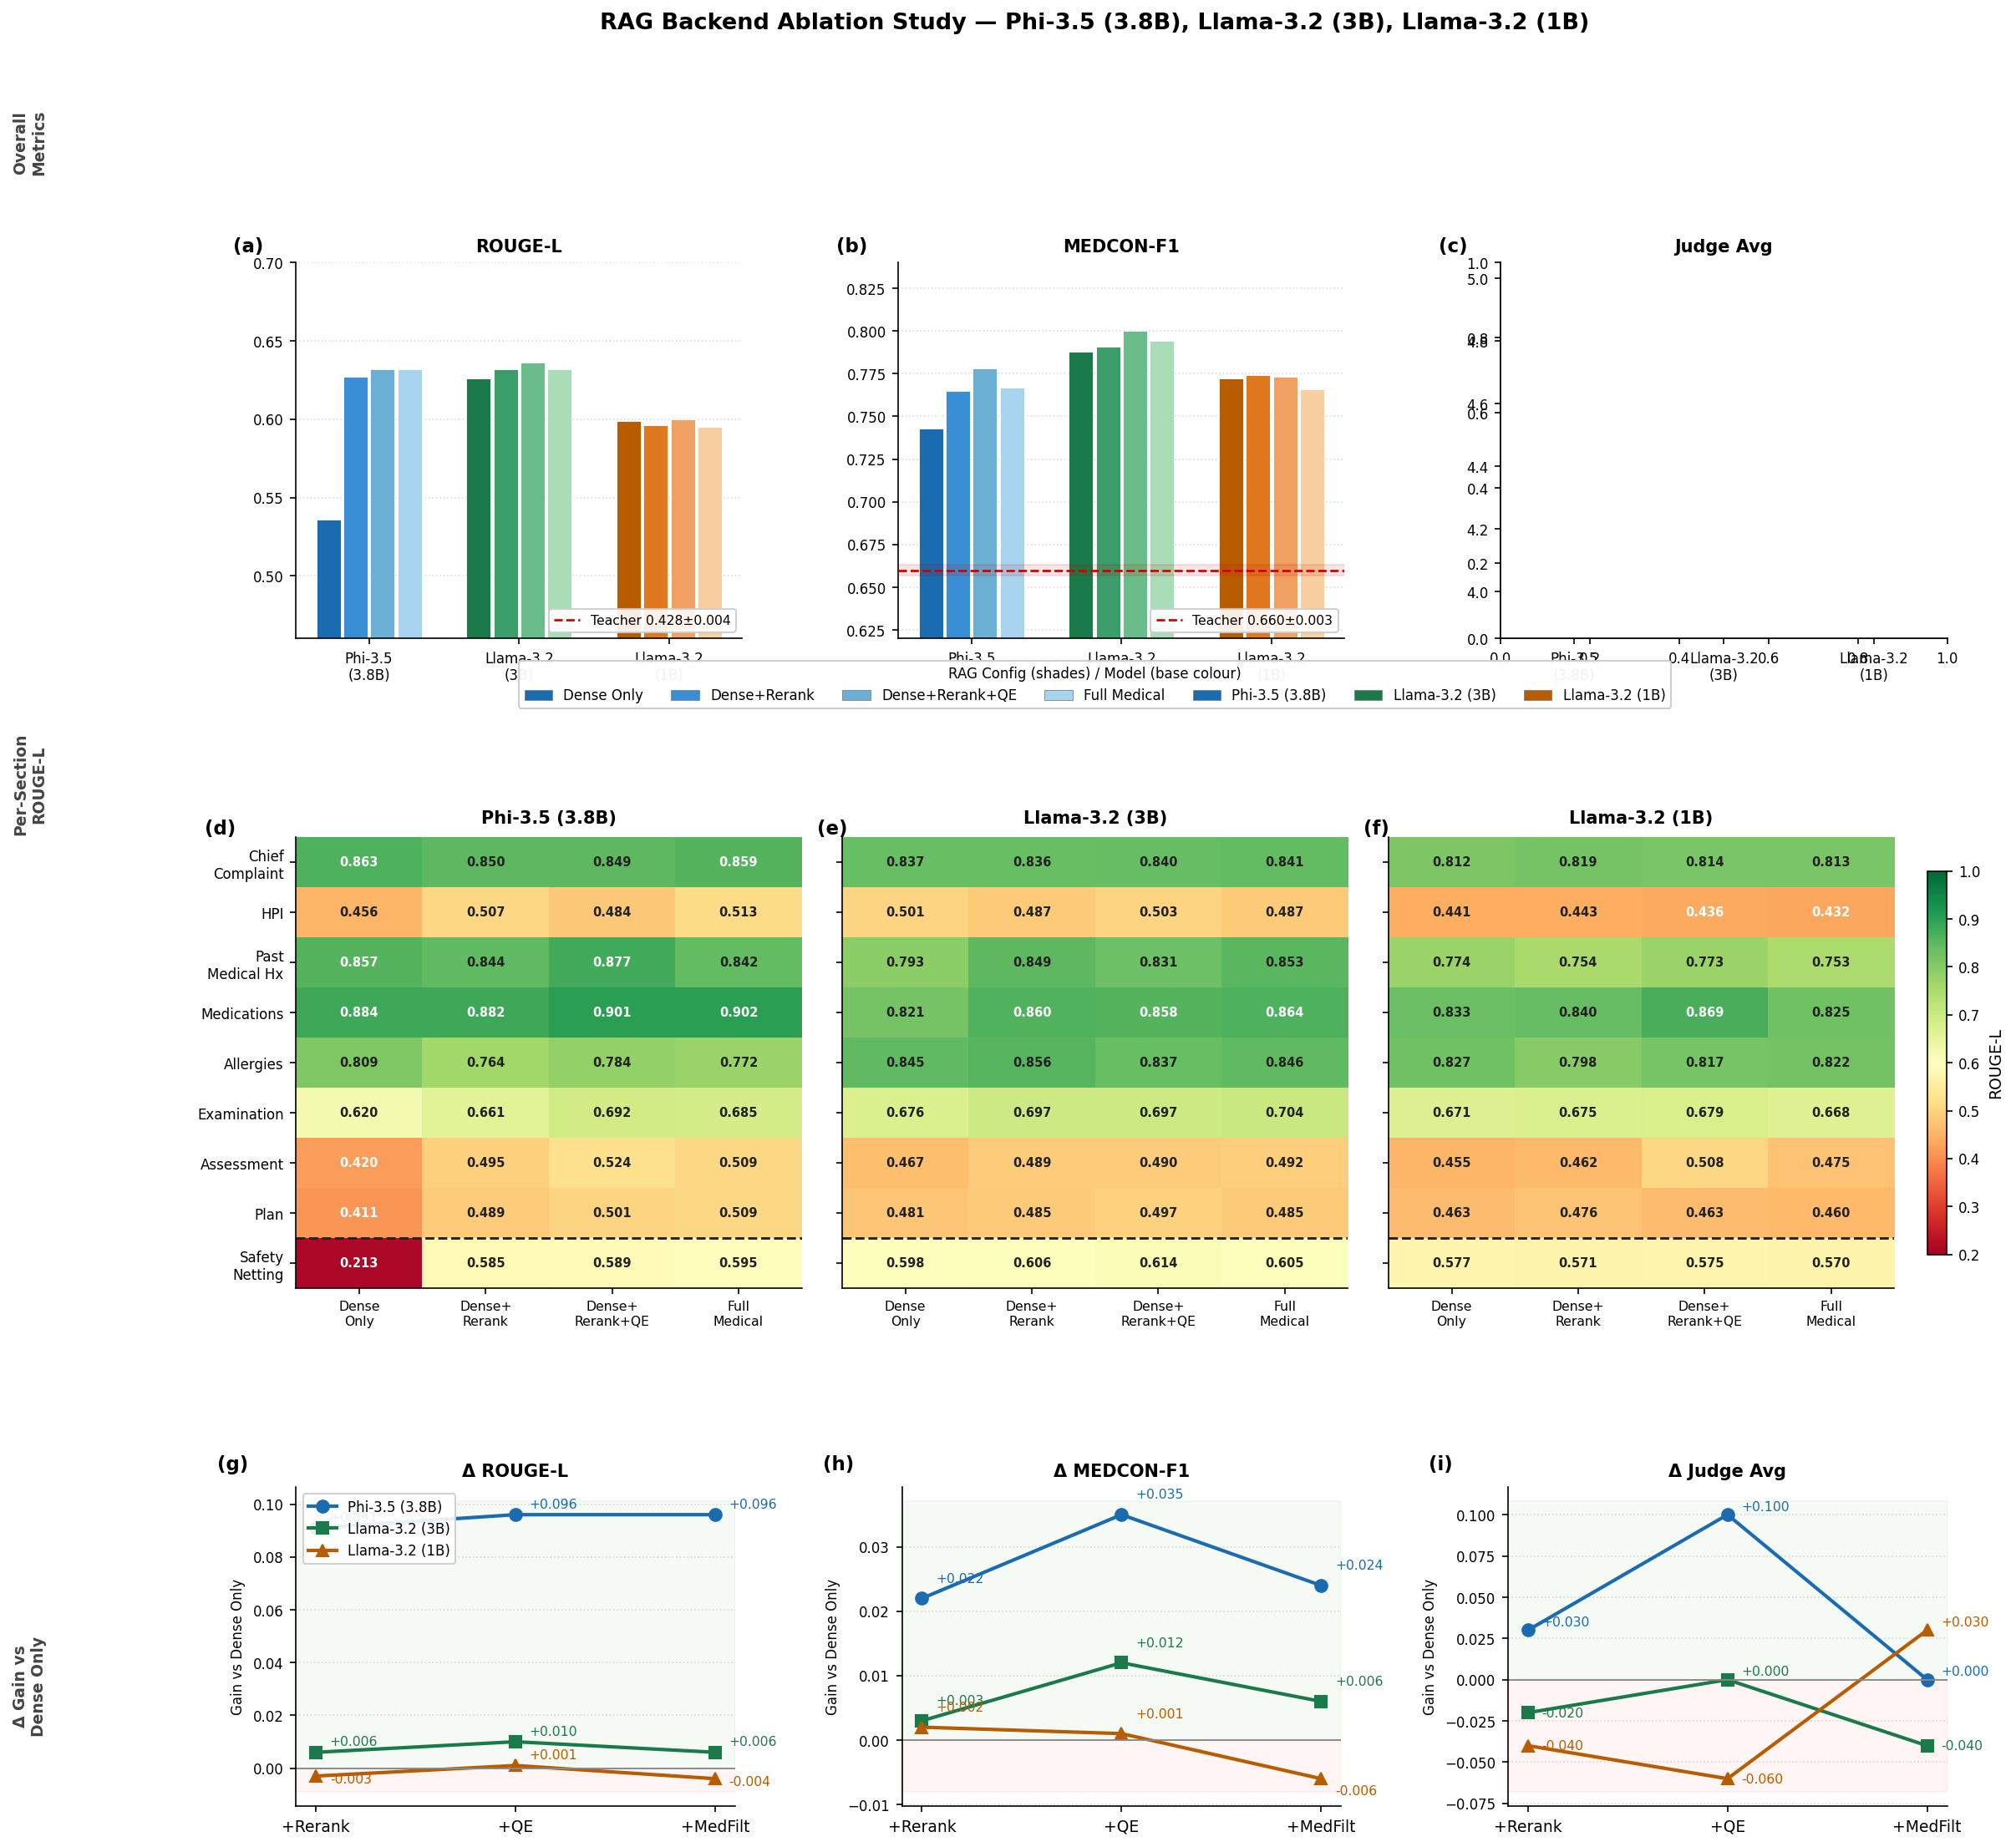

Saved: figure_rag_ablation_composite.png (300 DPI)


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# COMPOSITE FIGURE
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(17, 16))

# Outer grid: 3 rows
outer = gridspec.GridSpec(3, 1, figure=fig,
                          hspace=0.52,
                          height_ratios=[1.0, 1.2, 0.85])

# ── Row 1: Overall metrics (3 subplots) ──────────────────────────────────────
row1 = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer[0], wspace=0.35)
PLOT_METRICS = ['ROUGE-L', 'MEDCON-F1', 'Judge Avg']
YLIMS   = [(0.46, 0.70), (0.62, 0.84), (3.85, 5.05)]
panel_labels = list('abcdefghi')
pl = 0

n_models  = len(MODELS)
n_configs = len(CONFIGS)
bar_w     = 0.18
offsets   = np.linspace(-(n_configs-1)/2*bar_w, (n_configs-1)/2*bar_w, n_configs)

for col, (metric, ylim) in enumerate(zip(PLOT_METRICS, YLIMS)):
    ax = fig.add_subplot(row1[col])

    for m_idx in range(n_models):
        for c_idx in range(n_configs):
            val = overall[metric][m_idx][c_idx]
            x   = m_idx + offsets[c_idx]
            ax.bar(x, val, width=bar_w*0.90,
                   color=MODEL_COLS[m_idx][c_idx],
                   edgecolor='white', linewidth=0.4)

    # Teacher line
    t_m, t_s = teacher[metric]
    ax.axhline(t_m, color='#CC0000', linestyle='--',
               linewidth=1.3, zorder=5, label=f'Teacher {t_m:.3f}±{t_s:.3f}')
    ax.axhspan(t_m - t_s, t_m + t_s, alpha=0.10, color='#CC0000', zorder=4)

    ax.set_ylim(ylim)
    ax.set_xticks(range(n_models))
    ax.set_xticklabels(MODELS, fontsize=8)
    ax.set_title(metric, fontweight='bold', pad=6)
    ax.yaxis.grid(True, linestyle=':', alpha=0.45, zorder=0)
    ax.set_axisbelow(True)
    ax.legend(loc='lower right', fontsize=7.5, framealpha=0.9)

    # Panel label
    ax.text(-0.14, 1.07, f'({panel_labels[pl]})',
            transform=ax.transAxes, fontsize=11,
            fontweight='bold', va='top')
    pl += 1

# Row 1 legend for configs
config_patches = [
    mpatches.Patch(facecolor=MODEL_COLS[0][i], label=CONFIGS[i],
                   edgecolor='grey', linewidth=0.4)
    for i in range(n_configs)
]
model_patches = [
    mpatches.Patch(facecolor=MODEL_BASE[i], label=MODELS_FULL[i],
                   edgecolor='grey', linewidth=0.4)
    for i in range(n_models)
]
leg1 = fig.add_subplot(row1[0])
leg1.set_visible(False)
ax_r1_last = fig.add_subplot(row1[2])

# Place shared legends below Row 1
row1_axes = [fig.axes[i] for i in range(3)]
fig.legend(handles=config_patches + model_patches,
           ncol=7,
           loc='upper center',
           bbox_to_anchor=(0.5, 0.685),
           fontsize=8, framealpha=0.95,
           title='RAG Config (shades) / Model (base colour)',
           title_fontsize=8)

# ── Row 2: Section heatmaps ───────────────────────────────────────────────────
row2 = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer[1],
                                        wspace=0.08)
cmap = plt.cm.RdYlGn
vmin, vmax = 0.20, 1.00

hm_axes = []
for col, m_idx in enumerate(range(n_models)):
    ax = fig.add_subplot(row2[col])
    hm_axes.append(ax)

    mat = np.array(section_rouge[m_idx])  # shape (4 configs, 9 sections)
    mat = mat.T                            # shape (9 sections, 4 configs)

    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')

    for r in range(len(SECTIONS)):
        for c in range(len(CONFIGS)):
            v    = mat[r, c]
            norm = (v - vmin) / (vmax - vmin)
            tc   = 'white' if norm < 0.30 or norm > 0.82 else '#222222'
            ax.text(c, r, f'{v:.3f}',
                    ha='center', va='center',
                    fontsize=7, color=tc, fontweight='bold')

    ax.set_title(MODELS_FULL[m_idx], fontweight='bold', pad=8)
    ax.set_xticks(range(len(CONFIGS)))
    ax.set_xticklabels(['Dense\nOnly','Dense+\nRerank',
                        'Dense+\nRerank+QE','Full\nMedical'],
                       fontsize=7.5)
    ax.set_yticks(range(len(SECTIONS)))

    if col == 0:
        ax.set_yticklabels(SECTIONS, fontsize=8)
    else:
        ax.set_yticklabels([])

    # Separator before Safety Netting
    ax.axhline(7.5, color='#222222', linewidth=1.4, linestyle='--')

    ax.text(-0.18 if col == 0 else -0.05, 1.04,
            f'({panel_labels[pl]})',
            transform=ax.transAxes, fontsize=11,
            fontweight='bold', va='top')
    pl += 1

# Colourbar for heatmap
cbar = fig.colorbar(im, ax=hm_axes,
                    orientation='vertical',
                    fraction=0.012, pad=0.02,
                    shrink=0.85)
cbar.set_label('ROUGE-L', fontsize=9)
cbar.ax.tick_params(labelsize=8)

# ── Row 3: Delta gains ────────────────────────────────────────────────────────
row3 = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer[2], wspace=0.38)
UPGRADE_CONFIGS = ['Dense+Rerank', 'Dense+Rerank+QE', 'Full Medical']
UPGRADE_LABELS  = ['+Rerank', '+QE', '+MedFilt']

for col, metric in enumerate(PLOT_METRICS):
    ax = fig.add_subplot(row3[col])

    for m_idx in range(n_models):
        baseline = overall[metric][m_idx][0]
        deltas   = [
            overall[metric][m_idx][CONFIGS.index(cfg)] - baseline
            for cfg in UPGRADE_CONFIGS
        ]
        ax.plot([0,1,2], deltas,
                marker=MODEL_MARK[m_idx],
                color=MODEL_BASE[m_idx],
                linewidth=2, markersize=7,
                label=MODELS_FULL[m_idx])
        for xi, d in enumerate(deltas):
            va  = 'bottom' if d >= 0 else 'top'
            off = 0.0025 if d >= 0 else -0.0025
            ax.annotate(f'{d:+.3f}',
                        xy=(xi, d),
                        xytext=(xi + 0.07, d + off),
                        fontsize=7.5,
                        color=MODEL_BASE[m_idx])

    ax.axhline(0, color='#888888', linewidth=0.9)
    ax.set_title(f'Δ {metric}', fontweight='bold', pad=6)
    ax.set_xticks([0,1,2])
    ax.set_xticklabels(UPGRADE_LABELS, fontsize=9)
    ax.set_ylabel('Gain vs Dense Only', fontsize=8)
    ax.yaxis.grid(True, linestyle=':', alpha=0.45)
    ax.set_axisbelow(True)

    ylim = ax.get_ylim()
    if ylim[1] > 0:
        ax.axhspan(0, ylim[1], alpha=0.04, color='green', zorder=0)
    if ylim[0] < 0:
        ax.axhspan(ylim[0], 0, alpha=0.04, color='red', zorder=0)

    if col == 0:
        ax.legend(fontsize=8, loc='upper left', framealpha=0.9)

    ax.text(-0.18, 1.10, f'({panel_labels[pl]})',
            transform=ax.transAxes, fontsize=11,
            fontweight='bold', va='top')
    pl += 1

# ── Overall figure title ──────────────────────────────────────────────────────
fig.suptitle(
    'RAG Backend Ablation Study — Phi-3.5 (3.8B), Llama-3.2 (3B), Llama-3.2 (1B)',
    fontsize=13, fontweight='bold', y=1.005
)

# ── Row labels ────────────────────────────────────────────────────────────────
row_labels = [
    (0.000, 0.94, 'Overall\nMetrics'),
    (0.000, 0.62, 'Per-Section\nROUGE-L'),
    (0.000, 0.17, 'Δ Gain vs\nDense Only'),
]
for x, y, label in row_labels:
    fig.text(x, y, label, fontsize=9, fontweight='bold',
             color='#444444', va='center',
             rotation=90, ha='center')

plt.savefig('figure_rag_ablation_composite.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figure_rag_ablation_composite.png (300 DPI)')

## Suggested dissertation caption

**Figure X.** RAG backend ablation study across three fine-tuned student models on a 50-sample test set.
*(a–c)* Overall ROUGE-L, MEDCON-F1, and LLM-as-a-Judge scores for all four RAG configurations;
red dashed line shows teacher (GPT-4o-mini) mean ± SD reference.
*(d–f)* Per-section ROUGE-L heatmap across nine clinical summary sections;
dashed horizontal line separates narrative sections from Safety Netting.
*(g–i)* Delta gains in ROUGE-L, MEDCON-F1, and Judge Avg relative to the Dense Only baseline,
showing that retrieval sophistication benefits larger models substantially but yields marginal
gains for Llama-3.2 (1B).
Config abbreviations: Dense+Rerank+QE = dense retrieval + cross-encoder reranking + query expansion;
Full Medical = Dense+Rerank+QE + medical domain filtering.
